#  Credit Card Customer Segmentation

In this guided project, we’ll play the role of a data scientist working for a credit card company.The dataset contains information about the company’s clients and we're asked to help segment them into different groups in order to apply different business strategies for each type of customer.

Also, in a planning meeting with the Data Science coordinator, it was decided that we should use the K-means algorithm to segment the data.

The company expects to receive a group for each client and an explanation of the characteristics of each group and the main points that make them different.


In order to use the algorithm properly and achieve all the goals that the company has set for us, we'll go through the following steps:

- Analyze the dataset;
- Prepare the data for modeling;
- Find an appropriate number of clusters;
- Segment the data;
- Interpret and explain the results.


## Data Exploration

In [1]:
# import necessary module
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Read the dataset

customer = pd.read_csv('../../dataset/customer_segmentation.csv')
customer.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000


In [3]:
# print the number of rows and column in the dataset
customer.shape

(10127, 14)

There are `10127` rows and `14` feature column in the dataset

In [4]:
# print additional information in the dataset
print(customer.dtypes)
print(customer.isna().sum())


customer_id                   int64
age                           int64
gender                       object
dependent_count               int64
education_level              object
marital_status               object
estimated_income              int64
months_on_book                int64
total_relationship_count      int64
months_inactive_12_mon        int64
credit_limit                float64
total_trans_amount            int64
total_trans_count             int64
avg_utilization_ratio       float64
dtype: object
customer_id                 0
age                         0
gender                      0
dependent_count             0
education_level             0
marital_status              0
estimated_income            0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
credit_limit                0
total_trans_amount          0
total_trans_count           0
avg_utilization_ratio       0
dtype: int64


There are three categorical column in the dataset. i.e gender, education_level, and marital status. We will use dummies variable to deal with categorical variable.

There are no missing value in the dataset.

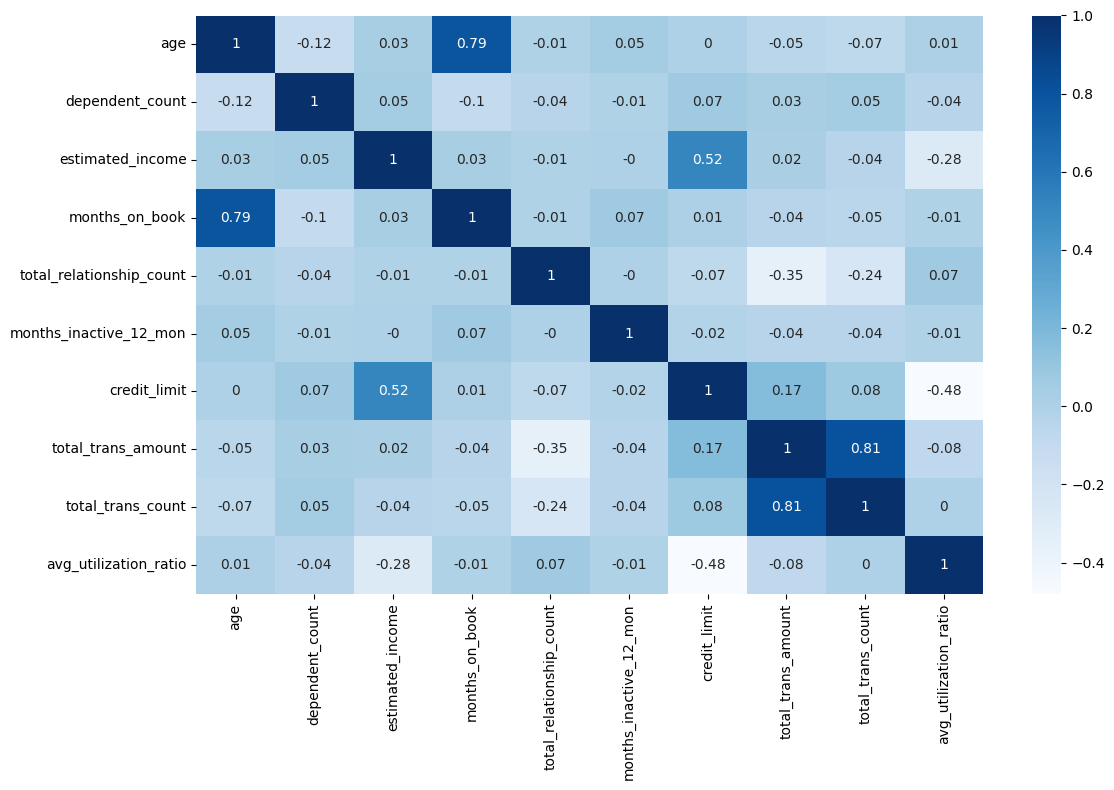

In [5]:
# check the correlation between columns to select the feature.
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(round(customer.drop('customer_id', axis=1).corr(numeric_only = True), 2), cmap='Blues', annot=True, ax=ax)

plt.tight_layout()
plt.show()

Most of the variables present weak correlations between each other, but there are some we can highlight:

* Age is strongly correlated with how long the person has been a customer (months_on_book);
* Credit limit is positively correlated with the estimated income and negatively correlated with the average utilization ratio;
* The total number of transactions (total_trans_count) is strongly correlated with the total amount transitioned (total_trans_amount).


/tmp/ipykernel_323/2544037232.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  customer.drop('customer_id', axis=1).hist(ax=ax)


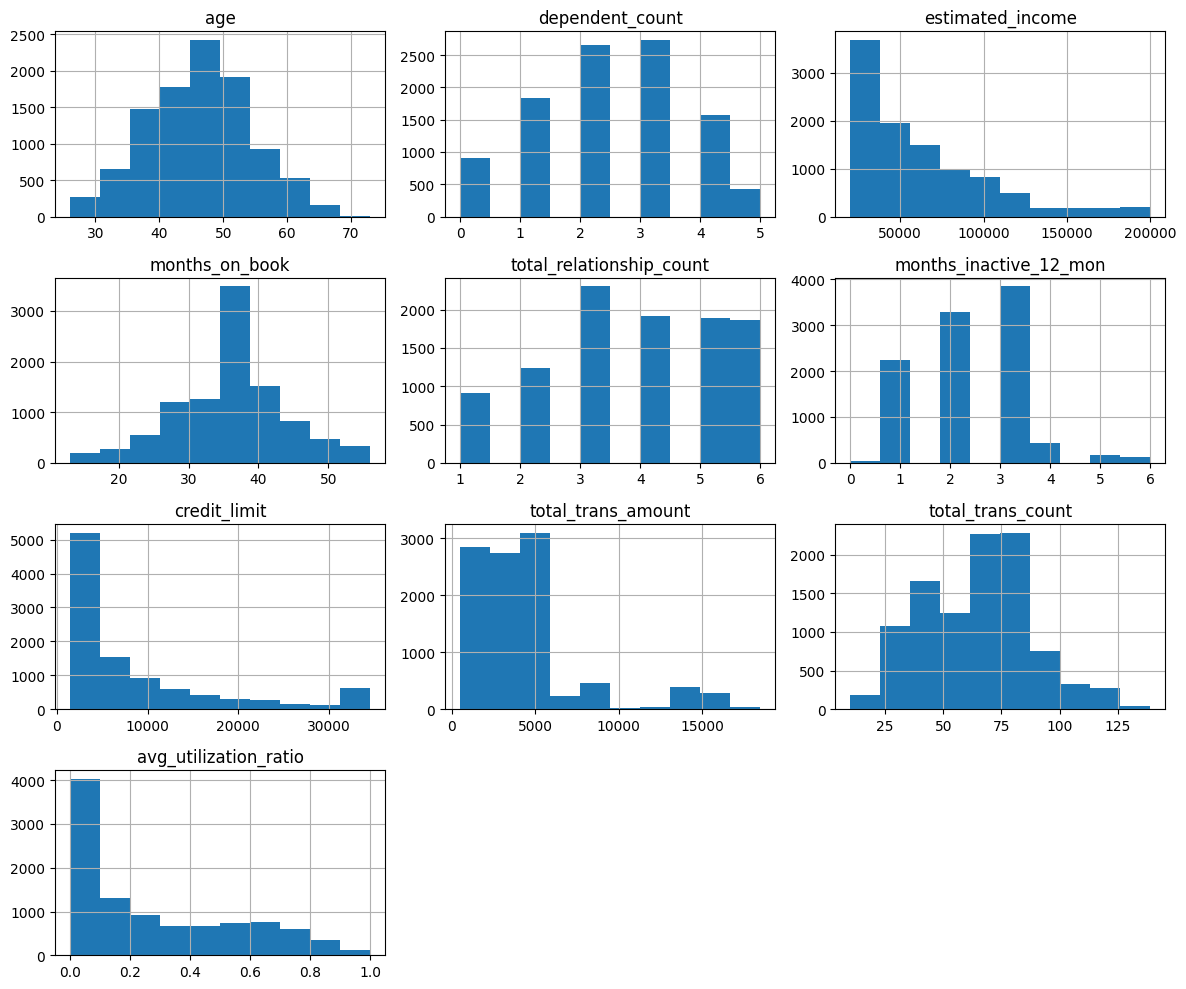

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

#Removing the customer's id before plotting the distributions
customer.drop('customer_id', axis=1).hist(ax=ax)

plt.tight_layout()
plt.show()

Some of the distribution are normal and rest of them are skewed.

## Feature Engineering

Let's start dealing with the categorical columns. There are three of them: gender, education level, and marital status.

The gender column contains only 2 unique values, "M" and "F", which means it's possible to replace all the rows with 1 and 0.

The education_level column contains 6 unique values. This column represents levels of education, and it's possible to rank the levels from the lowest to the highest, so it's possible to replace each unique level with a number, assuming we respect the order.

This is how to we execute this replacement.
- Uneducated : 0
- High School : 1
- College : 2
- Graduate : 3
- Post-Graduate : 4
- Doctorate : 5

The marital_status columns. This column contains these unique values:

- Single
- Married
- Divorced
- Unknown

Unfortunately, we can't do the same for this marital_status column as for the last categorical column. As we can see, unlike the education_level column, there is no level of magnitude between "Single", "Married" or "Divorced", for example. We can't say that any of them is higher or better than the others, which means we can't rank these categories objectively.

Therefore, we'll use one-hot-encoding to create dummy variables from this column.

In [7]:
# create a copy of the original DataFrame
customers_modif = customer.copy()
# Replace the value in gender column with 1 for 'M' and 0 for 'F'
customers_modif['gender'] = customers_modif['gender'].apply(lambda x: 1 if x == 'M' else 0)

# Replace the Value in education_level column
dict_map = {'Uneducated':0, 'High School':1, 'College':2, 'Graduate':3, 'Post-Graduate':4, 'Doctorate':5}
customers_modif['education_level'] = customers_modif['education_level'].map(dict_map)
customers_modif.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,1,3,1,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,0,5,3,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,1,3,3,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,0,4,1,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,1,3,0,Married,65000,21,5,1,4716.0,816,28,0.000


In [8]:
# Replace the marital status column
customers_modif = pd.get_dummies(customers_modif, columns = ['marital_status'], drop_first =True)
customers_modif.head()

,customer_id,age,gender,dependent_count,education_level,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,marital_status_Married,marital_status_Single,marital_status_Unknown
0,768805383,45,1,3,1,69000,39,5,1,12691.0,1144,42,0.061,True,False,False
1,818770008,49,0,5,3,24000,44,6,1,8256.0,1291,33,0.105,False,True,False
2,713982108,51,1,3,3,93000,36,4,1,3418.0,1887,20,0.000,True,False,False
3,769911858,40,0,4,1,37000,34,3,4,3313.0,1171,20,0.760,False,False,True
4,709106358,40,1,3,0,65000,21,5,1,4716.0,816,28,0.000,True,False,False


In [9]:
customers_modif.shape

(10127, 16)

## Scaling the Data

The estimated_income, for instance, contains numbers in the range of dozens and hundreds of thousands, while the dependent_count column contains numbers from 1 to 5.

At this point of the project we need to transform the data so it's all on the same scale.

In [11]:
# Create a new DataFrame without the column customer_id

X = customers_modif.drop(['customer_id'], axis = 1)

# Instantiate an object 
scaler = StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

X = pd.DataFrame(X_scaled)
X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-0.165406,1.059956,0.503368,-0.752211,0.175810,0.384621,0.763943,-1.327136,0.446622,-0.959707,-0.973895,-0.775882,1.077338,-0.798507,-0.282609
1,0.333570,-0.943436,2.043199,0.662787,-0.967166,1.010715,1.407306,-1.327136,-0.041367,-0.916433,-1.357340,-0.616276,-0.928214,1.252337,-0.282609
2,0.583058,1.059956,0.503368,0.662787,0.785397,0.008965,0.120579,-1.327136,-0.573698,-0.740982,-1.911206,-0.997155,1.077338,-0.798507,-0.282609
3,-0.789126,-0.943436,1.273283,-0.752211,-0.636973,-0.241473,-0.522785,1.641478,-0.585251,-0.951758,-1.911206,1.759686,-0.928214,-0.798507,3.538459
4,-0.789126,1.059956,0.503368,-1.459710,0.074212,-1.869317,0.763943,-1.327136,-0.430877,-1.056263,-1.570365,-0.997155,1.077338,-0.798507,-0.282609


## Choosing K

We'll have to create several models and compute the inertia from each of them. Then, we'll be able to plot the Elbow Curve and decide the number of clusters we'll use to segment the customers.

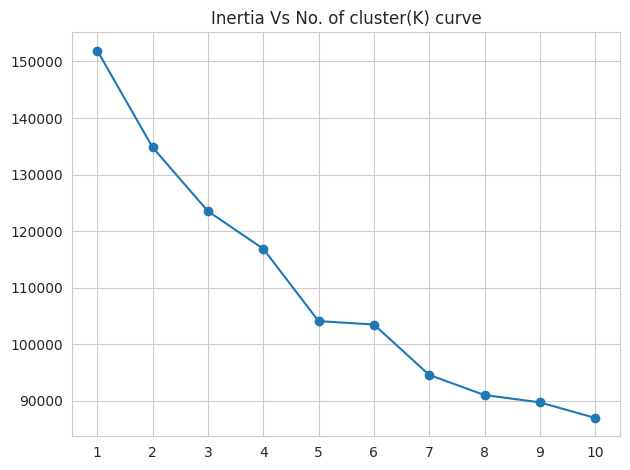

In [15]:
sns.set_style('whitegrid')
%matplotlib inline

inertia = list()
for i in range(1, 11):
    k_means = KMeans(n_clusters = i)
    k_means.fit_predict(X)
    inertia.append(k_means.inertia_)
    
plt.plot(range(1, 11), inertia, marker = 'o')
plt.title('Inertia Vs No. of cluster(K) curve')
plt.xticks(ticks=range(1, 11), labels=range(1, 11))
plt.tight_layout()
plt.show()


It seems like inertia is slowing decreasing between 5 and 7, so we choose 6.

In [17]:
K_means = KMeans(n_clusters = 6)
prediction = K_means.fit_predict(X_scaled)
print(prediction)

[1 4 1 ... 3 2 3]


## Analyzing Results

We need to see how the variables used in the clusterization differ from cluster to cluster in order better explain what each cluster represents.

We should note the most important characteristics of each cluster and how they can impact the business and marketing strategies for each type of customer.

In [25]:
customer['CLUSTER'] = prediction + 1
customer['CLUSTER'].value_counts()

CLUSTER
5    2771
4    2596
2    1863
1    1271
6     896
3     730
Name: count, dtype: int64

We can observe that cluster 5 and 4 have highest datapoint roughly more than `~50%`.

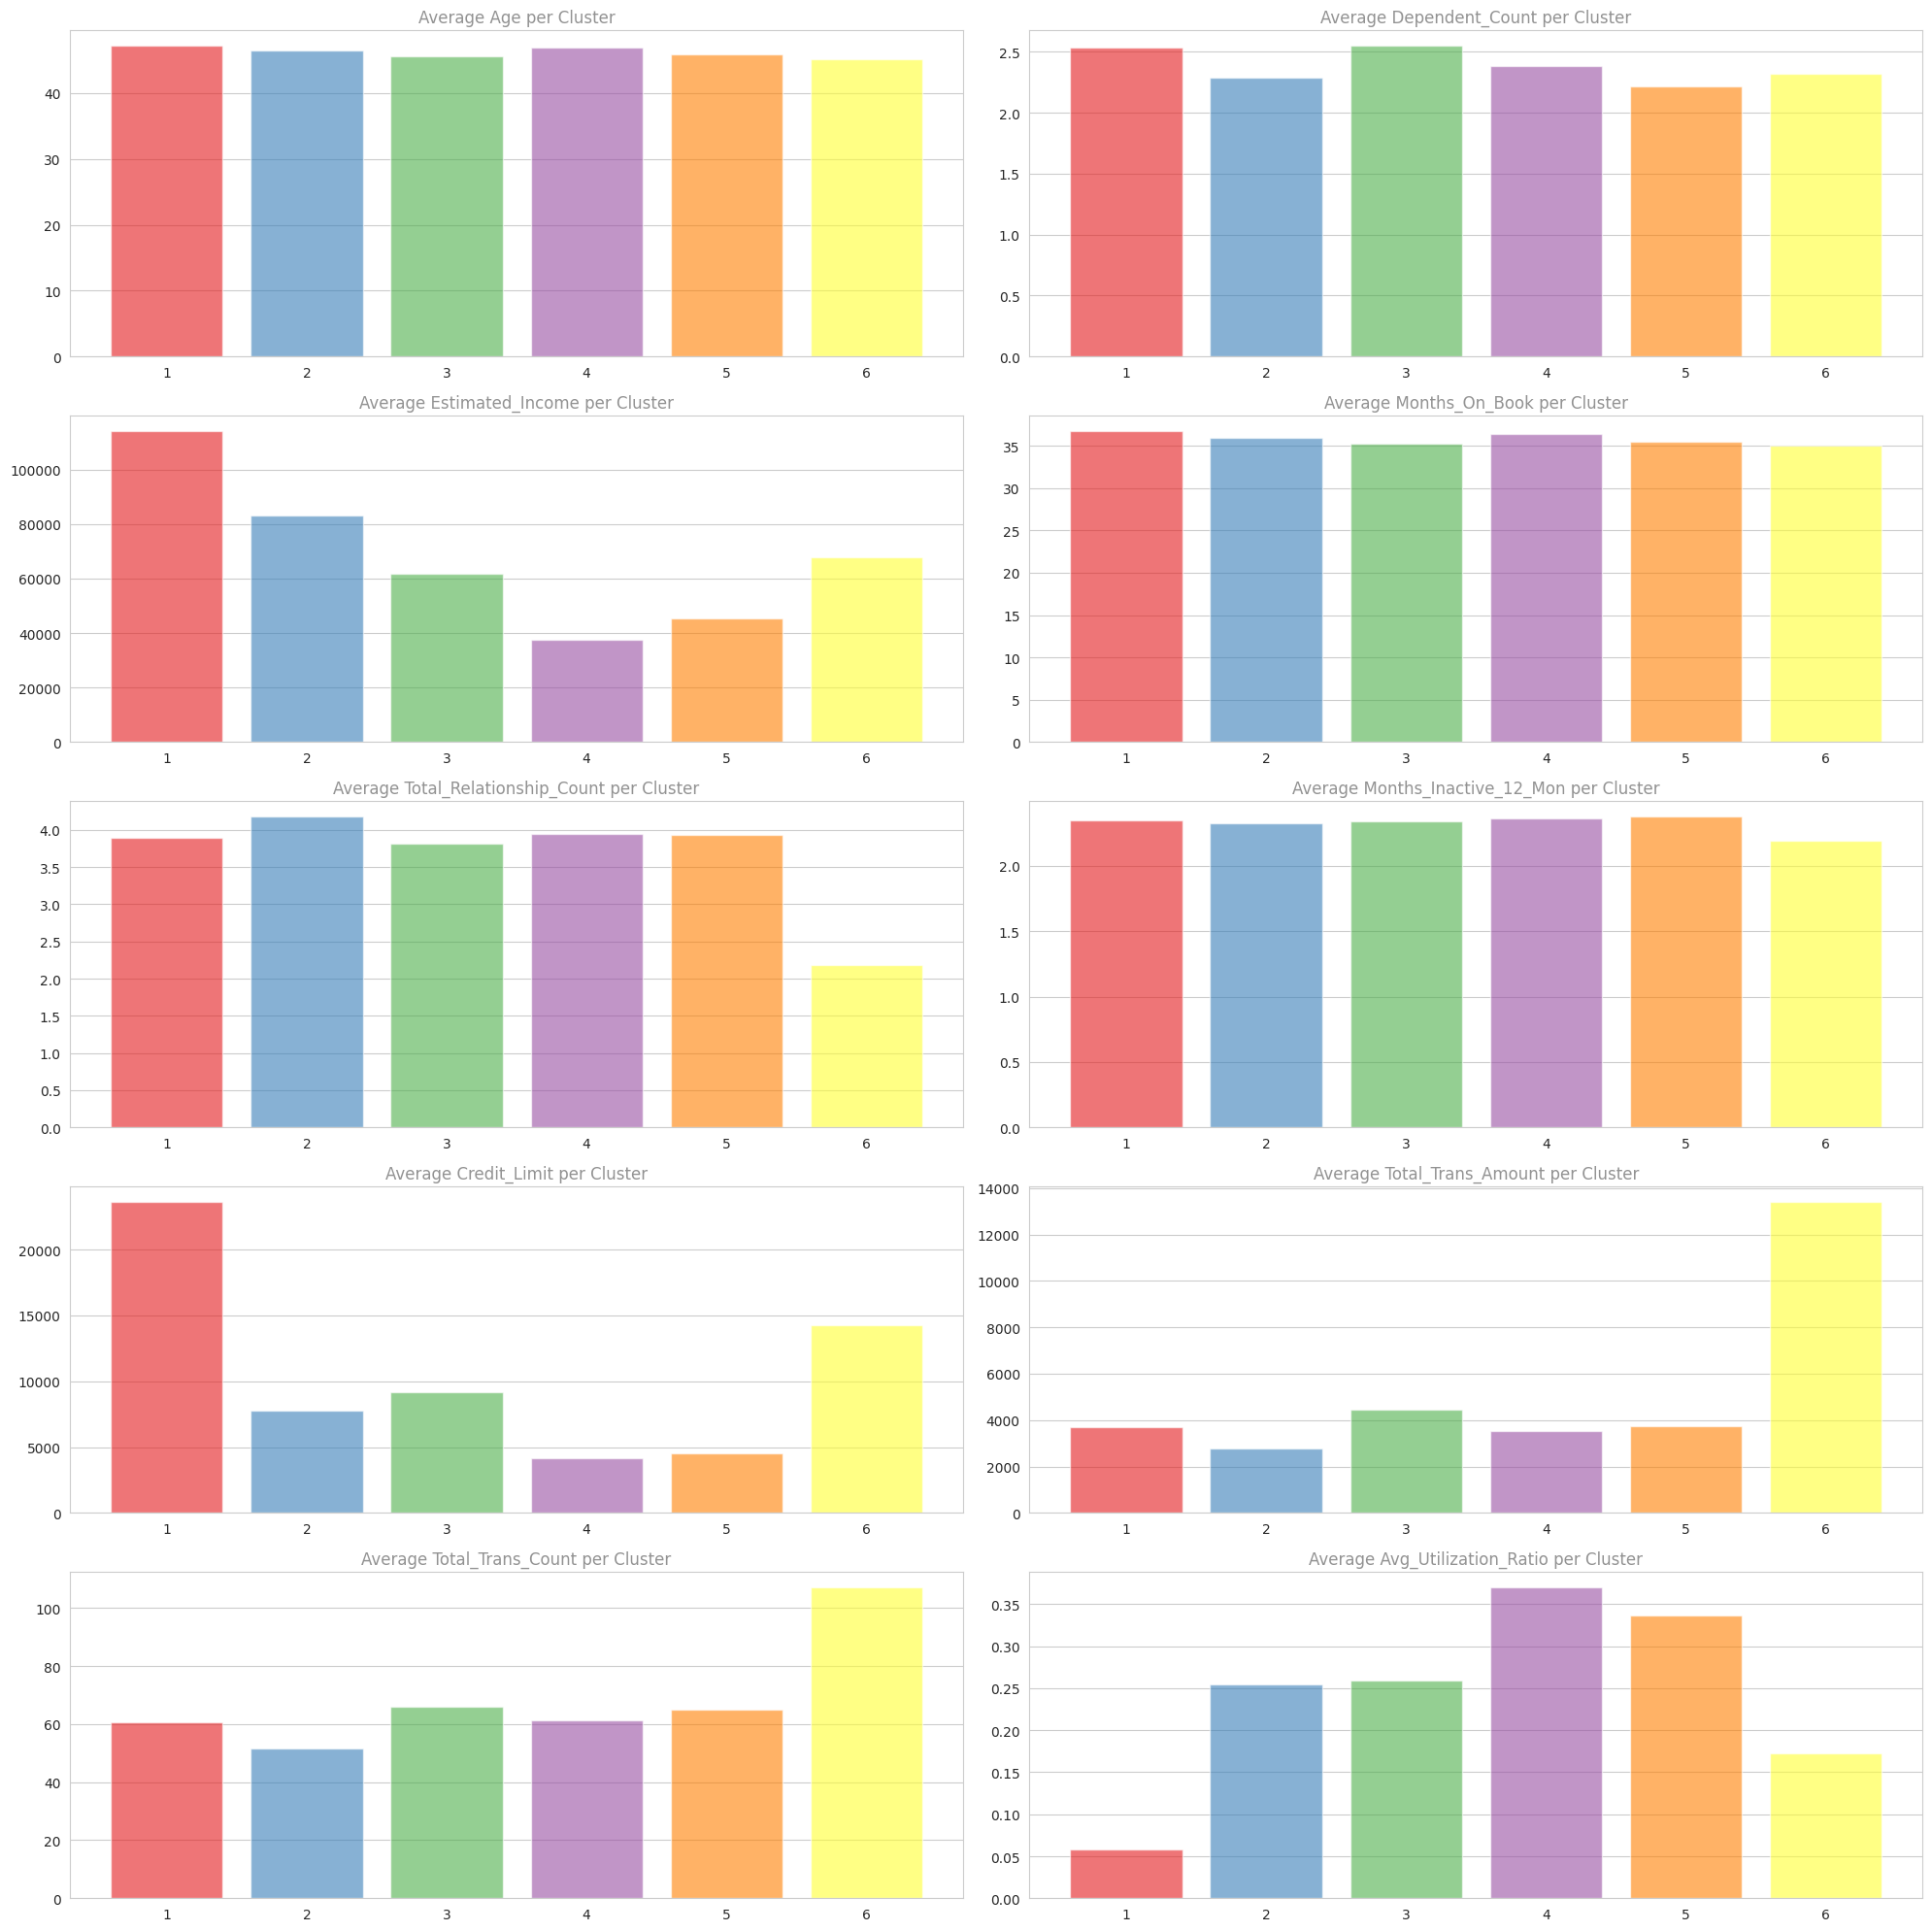

In [27]:
numeric_columns = customer.select_dtypes(include=np.number).drop(['customer_id', 'CLUSTER'], axis=1).columns

fig = plt.figure(figsize=(20, 20))
for i, column in enumerate(numeric_columns):
    df_plot = customer.groupby('CLUSTER')[column].mean()
    ax = fig.add_subplot(5, 2, i+1)
    ax.bar(df_plot.index, df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    ax.set_title(f'Average {column.title()} per Cluster', alpha=0.5)
    ax.xaxis.grid(False)
    
plt.tight_layout()
plt.show()

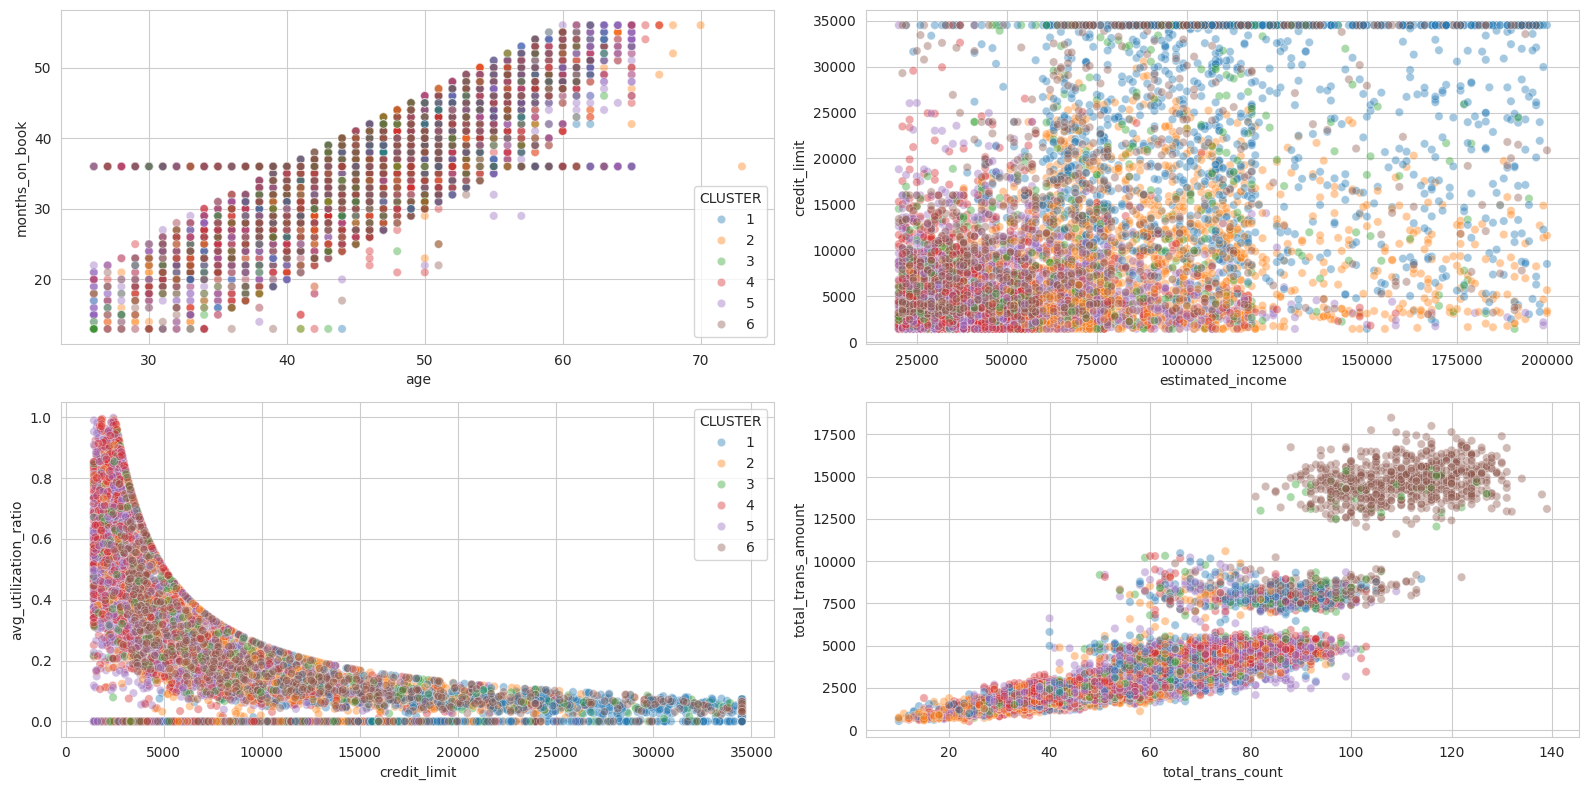

In [29]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))
sns.scatterplot(x='age', y='months_on_book', hue='CLUSTER', data=customer, palette='tab10', alpha=0.4, ax=ax1)
sns.scatterplot(x='estimated_income', y='credit_limit', hue='CLUSTER', data=customer, palette='tab10', alpha=0.4, ax=ax2, legend=False)
sns.scatterplot(x='credit_limit', y='avg_utilization_ratio', hue='CLUSTER', data=customer, palette='tab10', alpha=0.4, ax=ax3)
sns.scatterplot(x='total_trans_count', y='total_trans_amount', hue='CLUSTER', data=customer, palette='tab10', alpha=0.4, ax=ax4, legend=False)

plt.tight_layout()
plt.show()

We can draw some early conclusions considering only the numeric variables.

For instance, Cluster 1 has the highest amount of money transitioned, while Cluster 2 has the lowest credit limit and estimated income and the highest utilization rate. Cluster 4 has the highest credit limit. Older clients are grouped in Cluster 5.

For the categorical columns, we'll plot the percentual distribution of each variable in each cluster. This will allow us to verify if a particular cluster is mostly composed of men, or of married people only, for example.

/tmp/ipykernel_323/1026466811.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
/tmp/ipykernel_323/1026466811.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
/tmp/ipykernel_323/1026466811.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


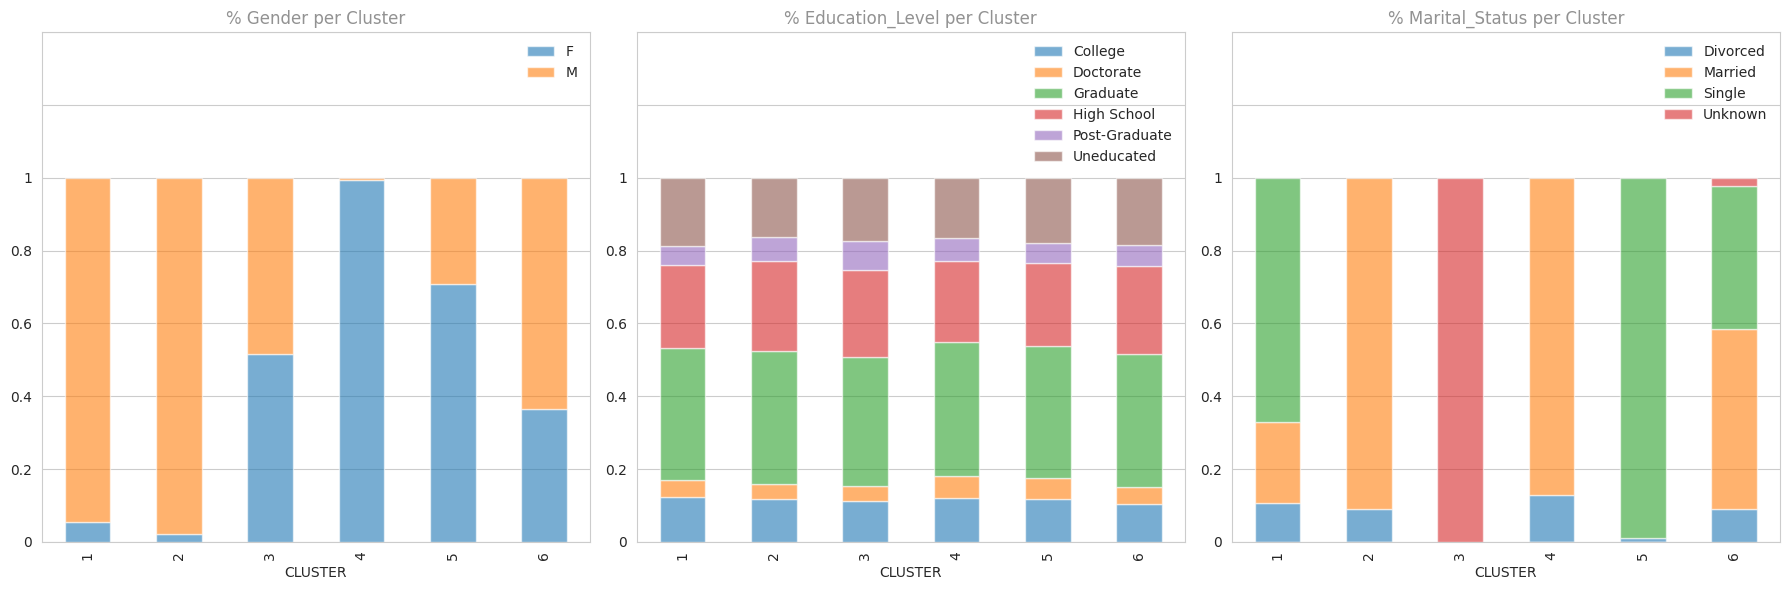

In [31]:
cat_columns = customer.select_dtypes(include=['object'])

fig = plt.figure(figsize=(18, 6))
for i, col in enumerate(cat_columns):
    plot_df = pd.crosstab(index=customer['CLUSTER'], columns=customer[col], values=customer[col], aggfunc='size', normalize='index')
    ax = fig.add_subplot(1, 3, i+1)
    plot_df.plot.bar(stacked=True, ax=ax, alpha=0.6)
    ax.set_title(f'% {col.title()} per Cluster', alpha=0.5)

    ax.set_ylim(0, 1.4)
    ax.legend(frameon=False)
    ax.xaxis.grid(False)
    
    labels = [0, 0.2, 0.4, 0.6, 0.8, 1]
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

Considering the categorical variables, we notice that the education level is well divided between clusters. 

In other highlights, Cluster 2 is composed almost entirely of married people, while we don't know the marital status of anybody in Cluster 3. Cluster 4 is almost completely male and Cluster 6 is 100% made of single people.

#Conclusion

As demanded by the company, we now have listed the most important characteristics of each cluster. We could also some suggestions and insights into each one of them.

In the end, we have the list of customers with a cluster assigned to each one.

###Cluster 1 

**Characteristics**: Mostly men; high credit limit; high amount transitioned; high number of transactions; low utilization rate. 

**Insight**: People with high volume spent on the card, but do not use it on a daily basis. Could be incentivised to spend more. 

###Cluster 2 

**Characteristics**: Mostly women;  mostly married; low estimated income; low credit limit; low amount transitioned; high utilization rate.

**Insight**: Married people (majority women) with low income and limit but utilize too much of their credit with a few larger purchases

###Cluster 3

**Cluster 3**: Gender well divided; low credit limit, high utilization rate; marital status 100% unknown; smaller cluster.

**Insight**: Men and women with low credit limits but do have high balances.

###Cluster 4

**Cluster 4**: Mostly men, mostly single and married, high estimated income, high credit limit; low amount transitioned; low utilization rate.

**Insight**: People (majority men) with high income and credit limits, but don't use the card. Could be incentivized to use it.

###Cluster 5

**Cluster 5**: Mostly married, high age, low dependent count, long time customers, low credit limit, low amount transitioned, high utilization rate.

**Insight**: Older people and long-time customers. Low credit limit and transactions, but use the card very often. Could receive benefits to spend more money.

###Cluster 6

**Cluster 6**: Mostly women; 100% single people, low estimated income, low credit limit, low amount transitioned, high utilization rate.

**Insight**: Single (mostly women) people that use their card a lot but have low credit limits and income. Could be given a bit more credit limit.